In [3]:
import kagglehub

path = kagglehub.dataset_download("atharvasoundankar/fashion-retail-sales")
print(path)

C:\Users\S Das\.cache\kagglehub\datasets\atharvasoundankar\fashion-retail-sales\versions\1


In [5]:
df = pd.read_csv(r"C:\Users\S Das\OneDrive\Documents\Fahion_Data.csv")
print(df)

      Customer_ID Item_Purchased  Purchase Date_Purchase  Review_Rating  \
0            4018        Handbag    4619.0    05-02-2023            NaN   
1            4115          Tunic    2456.0    11-07-2023            2.0   
2            4019       Tank Top    2102.0    23-03-2023            4.1   
3            4097       Leggings    3126.0    15-03-2023            3.2   
4            3997         Wallet    3003.0    27-11-2022            4.7   
...           ...            ...       ...           ...            ...   
3395         4118         Shorts      37.0    09-07-2023            2.7   
3396         4056       Slippers     176.0    16-03-2023            2.5   
3397         3991         Onesie       NaN    03-10-2022            2.4   
3398         4042        Sandals     128.0    01-01-2023            1.8   
3399         4001       Backpack     115.0    22-03-2023            1.4   

     Payment_Method  
0       Credit Card  
1       Credit Card  
2              Cash  
3          

In [86]:
df.iloc[10:20]

,Customer_ID,Item_Purchased,Purchase,Date_Purchase,Review_Rating,Payment_Method
10,4108,Slippers,2356.0,19-03-2023,4.8,Credit Card
11,4067,Bowtie,4418.0,21-11-2022,3.4,Cash
12,4068,Pajamas,3728.0,09-12-2022,NaN,Credit Card
13,4102,Trench Coat,2130.0,29-01-2023,4.8,Cash
14,4044,Handbag,2122.0,01-08-2023,1.2,Credit Card
15,4096,Poncho,2383.0,10-04-2023,NaN,Credit Card
16,4017,Gloves,2895.0,17-07-2023,3.6,Credit Card
17,4001,Trench Coat,2952.0,13-06-2023,2.2,Cash
18,3976,Slippers,4069.0,18-06-2023,4.9,Credit Card
19,4103,Romper,4465.0,21-11-2022,NaN,Credit Card


In [73]:
df.groupby('Item_Purchased')['Purchase'].agg(['sum', 'mean', 'median','max']).head(3)


,sum,mean,median,max
Item_Purchased,,,,
Backpack,6168.0,112.145455,120.0,197.0
Belt,10484.0,151.942029,94.0,3839.0
Blazer,9985.0,184.907407,119.5,4232.0


In [86]:
df.groupby('Confirmed').sum()

,Date,Country,Deaths,Recovered,Death_Rate
Confirmed,,,,,
1,01-01-2020,India,0,0,0.000000
2,01-01-2020,USA,0,0,-0.133333
3,02-01-2020,India,0,1,inf
5,02-01-2020,USA,0,1,inf
7,03-01-2020,India,1,2,7.000000
10,03-01-2020,USA,0,3,inf
20,04-01-2020,India,1,5,inf
25,04-01-2020,USA,1,10,25.000000
50,05-01-2020,India,2,15,50.000000


In [125]:
df[(df['Purchase'] > 3000) & (df['Payment_Method'] == "Credit Card")]

,Customer_ID,Item_Purchased,Purchase,Date_Purchase,Review_Rating,Payment_Method
0,4108,Handbag,4619.0,05-02-2023,NaN,Credit Card
9,4108,Loafers,4233.0,11-06-2023,NaN,Credit Card
12,4108,Pajamas,3728.0,09-12-2022,NaN,Credit Card
18,4108,Slippers,4069.0,18-06-2023,4.9,Credit Card
19,4108,Romper,4465.0,21-11-2022,NaN,Credit Card
23,4108,Flip-Flops,4932.0,20-12-2022,4.0,Credit Card
24,4108,Tunic,4661.0,12-04-2023,1.2,Credit Card
26,4108,Blazer,4232.0,25-10-2022,2.7,Credit Card
27,4108,Boots,3718.0,10-09-2023,2.8,Credit Card
30,4108,Tunic,4413.0,23-12-2022,1.2,Credit Card


In [80]:
df.sort_values('Purchase', ascending=True)
df.nlargest(5, 'Review_Rating')

,Customer_ID,Item_Purchased,Purchase,Date_Purchase,Review_Rating,Payment_Method
34,3984,Sweater,4859.0,19-12-2022,5.0,Cash
196,4103,Jumpsuit,149.0,16-10-2022,5.0,Cash
203,3978,Handbag,37.0,17-01-2023,5.0,Cash
419,4098,Raincoat,79.0,04-02-2023,5.0,Credit Card
635,4074,Socks,67.0,31-10-2022,5.0,Credit Card


In [105]:
df.sort_values(by=['Purchase','Review_Rating','Payment_Method'], ascending=False).head(5)

,Customer_ID,Item_Purchased,Purchase,Date_Purchase,Review_Rating,Payment_Method
23,4108,Flip-Flops,4932.0,20-12-2022,4.0,Credit Card
25,4108,Shorts,4872.0,25-08-2023,3.8,Cash
34,4108,Sweater,4859.0,19-12-2022,5.0,Cash
8,4108,Jeans,4771.0,19-05-2023,4.1,Cash
24,4108,Tunic,4661.0,12-04-2023,1.2,Credit Card


In [113]:
df.pivot_table(index='Customer_ID', columns='Item_Purchased', values='Purchase', aggfunc='sum')

Item_Purchased,Backpack,Belt,Blazer,Blouse,Boots,Bowtie,Camisole,Cardigan,Coat,Dress,...,Swimsuit,T-shirt,Tank Top,Tie,Trench Coat,Trousers,Tunic,Umbrella,Vest,Wallet
Customer_ID,,,,,,,,,,,,,,,,,,,,,
4108,6168.0,10484.0,9985.0,10472.0,11891.0,8705.0,6136.0,9270.0,5554.0,4107.0,...,9026.0,9043.0,8296.0,4743.0,9992.0,6458.0,17275.0,5815.0,6190.0,9372.0


In [140]:
df.query("Review_Rating > 4")

,Customer_ID,Item_Purchased,Purchase,Date_Purchase,Review_Rating,Payment_Method
2,4108,Tank Top,2102.0,23-03-2023,4.1,Cash
4,4108,Wallet,3003.0,27-11-2022,4.7,Cash
5,4108,Onesie,2914.0,11-12-2022,4.5,Credit Card
7,4108,Trousers,2419.0,10-11-2022,4.6,Cash
8,4108,Jeans,4771.0,19-05-2023,4.1,Cash
...,...,...,...,...,...,...
3373,4108,Gloves,146.0,02-04-2023,4.8,Cash
3374,4108,Cardigan,NaN,27-08-2023,4.1,Cash
3380,4108,Coat,129.0,27-07-2023,4.7,Credit Card
3387,4108,Flip-Flops,93.0,12-04-2023,4.9,Cash


In [98]:
df.groupby('Country')['Deaths'].sum()

Country
India    44
USA      36
Name: Deaths, dtype: int64

In [123]:
df.to_csv()

',Customer_ID,Item_Purchased,Purchase,Date_Purchase,Review_Rating,Payment_Method\r\n0,4108,Handbag,4619.0,05-02-2023,,Credit Card\r\n1,4108,Tunic,2456.0,11-07-2023,2.0,Credit Card\r\n2,4108,Tank Top,2102.0,23-03-2023,4.1,Cash\r\n3,4108,Leggings,3126.0,15-03-2023,3.2,Cash\r\n4,4108,Wallet,3003.0,27-11-2022,4.7,Cash\r\n5,4108,Onesie,2914.0,11-12-2022,4.5,Credit Card\r\n6,4108,Jacket,2571.0,08-07-2023,1.3,Cash\r\n7,4108,Trousers,2419.0,10-11-2022,4.6,Cash\r\n8,4108,Jeans,4771.0,19-05-2023,4.1,Cash\r\n9,4108,Loafers,4233.0,11-06-2023,,Credit Card\r\n10,4108,Slippers,2356.0,19-03-2023,4.8,Credit Card\r\n11,4108,Bowtie,4418.0,21-11-2022,3.4,Cash\r\n12,4108,Pajamas,3728.0,09-12-2022,,Credit Card\r\n13,4108,Trench Coat,2130.0,29-01-2023,4.8,Cash\r\n14,4108,Handbag,2122.0,01-08-2023,1.2,Credit Card\r\n15,4108,Poncho,2383.0,10-04-2023,,Credit Card\r\n16,4108,Gloves,2895.0,17-07-2023,3.6,Credit Card\r\n17,4108,Trench Coat,2952.0,13-06-2023,2.2,Cash\r\n18,4108,Slippers,4069.0,18-06-2023,4.9,Credit

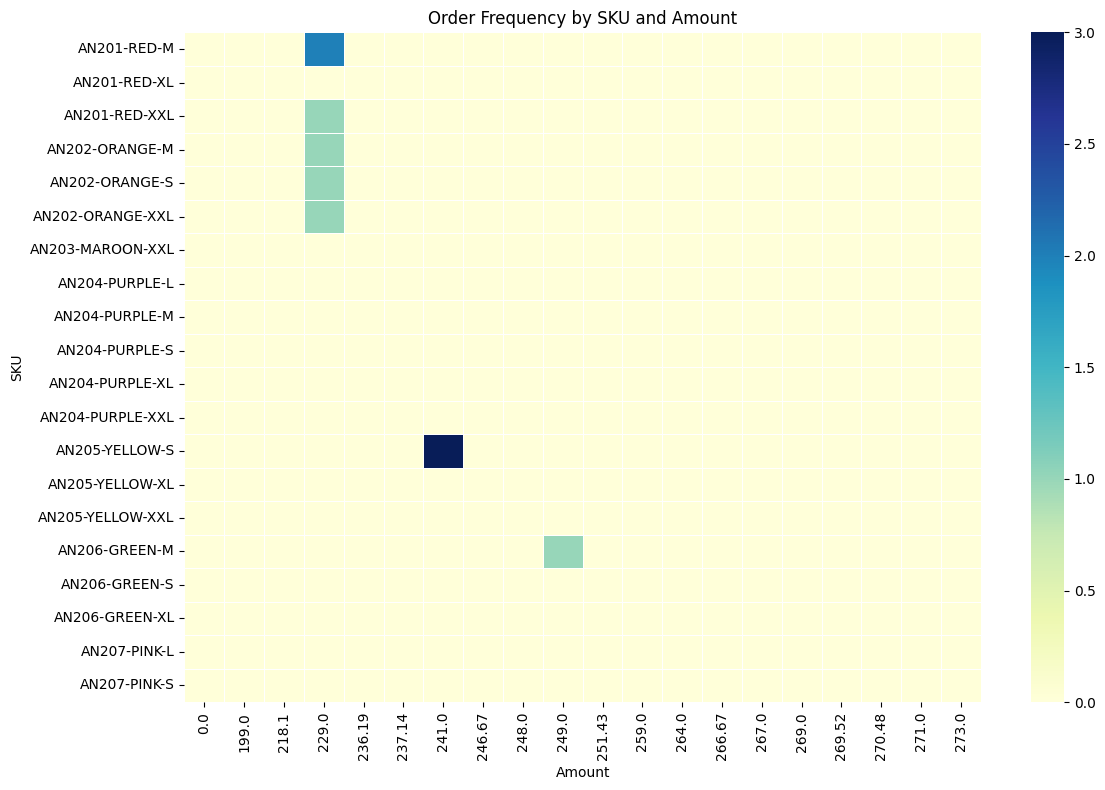

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV
df = pd.read_csv(r"C:\Users\S Das\Downloads\archive (2)\Amazon Sale Report.csv", low_memory=False)

# Clean and convert 'Amount' to numeric if needed
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df = df.dropna(subset=['SKU', 'Amount', 'Order ID'])

# Create a pivot table
hmap_data = df.pivot_table(
    index='SKU',
    columns='Amount',
    values='Order ID',
    aggfunc='count',
    fill_value=0
)

# Due to high cardinality, limit the pivot to top N values
hmap_data = hmap_data.iloc[:20, :20]  # Adjust as needed for clarity

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(hmap_data, cmap='YlGnBu', annot=False, linewidths=0.5)
plt.xlabel('Amount')
plt.ylabel('SKU')
plt.title('Order Frequency by SKU and Amount')
plt.tight_layout()
plt.show()
